I will now build a machine learning model to predict whether a patient is likely to be readmitted within 30 days after discharge. This is an important healthcare problem because 30-day readmissions are costly for hospitals, may indicate gaps in care, and are often used as a quality performance metric. By identifying high-risk patients early, hospitals can prioritize follow-up care, discharge planning, and preventive interventions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import shap


# ─────────────────────────────────────────────────────────────
# Plot Style
# ─────────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


# ─────────────────────────────────────────────────────────────
# Project Paths
# ─────────────────────────────────────────────────────────────
# I define folder paths once here so I can reuse them later.
# processed folder: contains cleaned/feature-engineered data
# models folder: will store trained models or encoders
PROCESSED = Path("../data/processed")
MODELS    = Path("../models")


# ─────────────────────────────────────────────────────────────
# Quick Environment Check
# ─────────────────────────────────────────────────────────────

print("Libraries loaded successfully")
print(f"XGBoost version : {xgb.__version__}")
print(f"SHAP version    : {shap.__version__}")

Libraries loaded successfully
XGBoost version : 3.2.0
SHAP version    : 0.49.1


In [2]:
df = pd.read_csv(
    PROCESSED / "admissions_clean.csv",
    parse_dates=["date_of_admission", "discharge_date"]
)

print(f"Shape: {df.shape}")
print(df.dtypes)

Shape: (55392, 18)
admission_id                    int64
name                           object
age                             int64
gender                         object
blood_type                     object
medical_condition              object
date_of_admission      datetime64[ns]
doctor                         object
hospital                       object
insurance_provider             object
billing_amount                float64
room_number                     int64
admission_type                 object
discharge_date         datetime64[ns]
medication                     object
test_results                   object
length_of_stay_days             int64
age_group                      object
dtype: object


In [3]:
# ─────────────────────────────────────────────────────────────
# Create Readmission Target Variable
# ─────────────────────────────────────────────────────────────
# The dataset does not directly give me a (readmitted within 30 days) column, so I create it using the admission and discharge dates.
#
# A patient is marked as readmitted if they have another hospital admission within 30 days after their discharge date.
#
# Important note:
# In a real hospital dataset, I should use a unique patient_id.
# In this dataset, I only have the patient name, so I use (name) as the patient identifier for this project.


# Make a sorted copy of the dataset.
# Sorting is important because I need each patient's admissions to be in chronological order before looking for the next admission.
df_sorted = df.sort_values(
    by=["name", "date_of_admission"]
).copy()


# For each patient, get their next admission date.
#
# Example:
# Admission 1 : next admission is Admission 2
# Admission 2 : next admission is Admission 3
# Last admission : no next admission, so the value will be missing
df_sorted["next_admission_date"] = (
    df_sorted
    .groupby("name")["date_of_admission"]
    .shift(-1) # look one row ahead within the same patient group.
)


# Calculate how many days passed between the current discharge date and the patient's next admission date.
#
# If the value is:
#   5   : the patient came back after 5 days
#   40  : the patient came back after 40 days
#   NaN : there was no later admission for that patient
df_sorted["days_to_readmission"] = (
    df_sorted["next_admission_date"] - df_sorted["discharge_date"]
).dt.days


# Create the target variable for the machine learning model.
#
# A value of 1 means the patient was readmitted within 30 days.
# I also check that the value is >= 0 to avoid counting cases where the next admission date appears before the discharge date.
df_sorted["readmitted_30d"] = (
    (df_sorted["days_to_readmission"] >= 0) &
    (df_sorted["days_to_readmission"] <= 30)
).astype(int)


# ─────────────────────────────────────────────────────────────
# Target Variable Summary
# ─────────────────────────────────────────────────────────────
# Before training a model, I check the balance of the target variable.
# This tells me how common 30-day readmissions are in the dataset.

total_admissions = len(df_sorted)
readmitted_count = df_sorted["readmitted_30d"].sum()
readmission_rate = readmitted_count / total_admissions * 100

print(f"Total admissions   : {total_admissions:,}")
print(f"Readmitted (30d)   : {readmitted_count:,}")
print(f"Readmission rate   : {readmission_rate:.1f}%")
print()

print("Readmission breakdown:")
print(df_sorted["readmitted_30d"].value_counts())

Total admissions   : 55,392
Readmitted (30d)   : 578
Readmission rate   : 1.0%

Readmission breakdown:
readmitted_30d
0    54814
1      578
Name: count, dtype: int64



After creating the `readmitted_30d` target variable, the dataset contains **55,392 total admissions**.

Out of these admissions, **578 cases** were followed by another admission within 30 days of discharge. This gives a 30-day readmission rate of approximately **1.0%**.

This shows that the target variable is highly imbalanced:

- **0 = Not readmitted within 30 days:** 54,814 admissions
- **1 = Readmitted within 30 days:** 578 admissions

This imbalance is important for the machine learning stage. A model could achieve very high accuracy by simply predicting that every patient was not readmitted, but that would not be useful in a healthcare setting.

Because the positive class is rare and clinically important, model evaluation should focus more on metrics such as **recall**, **F1-score**, **precision-recall AUC**, and the **confusion matrix**, rather than accuracy alone.

For this project, recall is especially important because missing a patient who is at risk of readmission could mean losing an opportunity for early follow-up care, discharge planning, or preventive intervention.

In [4]:
# ─────────────────────────────────────────────────────────────
# Select Model Features and Encode Categorical Columns
# ─────────────────────────────────────────────────────────────
# In this step, I prepare the dataset for machine learning.
#
# The goal is to keep only the columns that a hospital would realistically know at the time of discharge.
# This is important because the model should  not learn from future information, such as the next admission date.
#
# If future information is used during training, the model may look very accurate in the notebook but fail in real-world use.
# This problem is called data leakage.


# These are the input features that will be used to predict 30-day readmission.
# I selected patient details, admission information, clinical condition, test result, medication, and length of stay.
features = [
    "age",
    "age_group",
    "gender",
    "blood_type",
    "medical_condition",
    "admission_type",
    "insurance_provider",
    "length_of_stay_days",
    "billing_amount",
    "test_results",
    "medication",
]


# This is the target column the model will try to predict.
# 0 = not readmitted within 30 days
# 1 = readmitted within 30 days
target = "readmitted_30d"


# Create a separate modeling dataframe.
df_model = df_sorted[features + [target]].copy()


# ─────────────────────────────────────────────────────────────
# Encode Categorical Features
# ─────────────────────────────────────────────────────────────
# For this first version, I use LabelEncoder because it is simple and easy to understand. 
# Later, OneHotEncoder could also be tested, especially for models where category order may matter.


# Dictionary to store one encoder for each categorical column.
# This is useful later because I want to save the encoders and use them in a Streamlit app for new patient predictions.
encoders = {}


# List of columns that contain text/category values.
cat_cols = [
    "age_group",
    "gender",
    "blood_type",
    "medical_condition",
    "admission_type",
    "insurance_provider",
    "test_results",
    "medication",
]


for col in cat_cols:
    
    le = LabelEncoder()
    
    # Convert values to string first to avoid errors if there are missing values or mixed data types.
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    
    # Store the encoder so I can reuse it later.
    encoders[col] = le
    
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"{col}: {mapping}")




print(f"\nFinal modeling shape: {df_model.shape}")
print(f"Total null values   : {df_model.isnull().sum().sum()}")

age_group: {'0-17': 0, '18-34': 1, '35-54': 2, '55-74': 3, '75+': 4}
gender: {'Female': 0, 'Male': 1}
blood_type: {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
medical_condition: {'Arthritis': 0, 'Asthma': 1, 'Cancer': 2, 'Diabetes': 3, 'Hypertension': 4, 'Obesity': 5}
admission_type: {'Elective': 0, 'Emergency': 1, 'Urgent': 2}
insurance_provider: {'Aetna': 0, 'Blue Cross': 1, 'Cigna': 2, 'Medicare': 3, 'Unitedhealthcare': 4}
test_results: {'Abnormal': 0, 'Inconclusive': 1, 'Normal': 2}
medication: {'Aspirin': 0, 'Ibuprofen': 1, 'Lipitor': 2, 'Paracetamol': 3, 'Penicillin': 4}

Final modeling shape: (55392, 12)
Total null values   : 0


After selecting the modeling features, all categorical columns were encoded into numeric values using `LabelEncoder`.

This step was required because machine learning models cannot directly learn from text values such as gender, admission type, medical condition, insurance provider, medication, or test results. Each category was converted into a numeric label so the dataset can be used for model training.

For example:

- `gender`: Female = 0, Male = 1
- `admission_type`: Elective = 0, Emergency = 1, Urgent = 2
- `test_results`: Abnormal = 0, Inconclusive = 1, Normal = 2

The final modeling dataset contains **55,392 rows** and **12 columns**. These columns include **11 input features** and **1 target variable**: `readmitted_30d`.

The dataset also has **0 missing values**, which means it is ready for the next machine learning step: splitting the data into training and testing sets.

One important note is that `LabelEncoder` assigns numbers to categories, but these numbers do not always represent a real order. For example, blood type and medication categories are only encoded as numeric labels for the model, not because one category is higher or lower than another. This is acceptable for a first baseline model, but future improvements could test one-hot encoding for comparison.

In [5]:
# ─────────────────────────────────────────────────────────────
# Train / Test Split
# ─────────────────────────────────────────────────────────────
# Features used for prediction
X = df_model.drop(columns=[target])

# Target variable
# 0 = not readmitted within 30 days
# 1 = readmitted within 30 days
y = df_model[target]


# stratify=y is important because the readmission class is very rare around 1%.
# This keeps the same class balance in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ─────────────────────────────────────────────────────────────
# Split Validation
# ─────────────────────────────────────────────────────────────


print(f"Train size : {len(X_train):,} rows")
print(f"Test size  : {len(X_test):,} rows")
print()

print(f"Train readmission rate : {y_train.mean()*100:.1f}%")
print(f"Test readmission rate  : {y_test.mean()*100:.1f}%")

Train size : 44,313 rows
Test size  : 11,079 rows

Train readmission rate : 1.0%
Test readmission rate  : 1.0%


The final modeling dataset was split into a training set and a testing set using an 80/20 split.

The training set contains **44,313 records**, while the testing set contains **11,079 records**. The model will learn patterns from the training data and will later be evaluated on the testing data, which represents unseen admissions.

The readmission rate is approximately **1.0%** in both the training and testing sets. This confirms that the stratified split worked correctly and preserved the original class balance.

This is especially important because the target variable is highly imbalanced. Since only a small percentage of admissions result in a 30-day readmission, keeping the same positive-class rate in both datasets helps make the model evaluation more reliable.

=== Logistic Regression Baseline with Scaling ===
                precision    recall  f1-score   support

Not Readmitted       0.99      0.54      0.70     10963
    Readmitted       0.01      0.49      0.02       116

      accuracy                           0.54     11079
     macro avg       0.50      0.51      0.36     11079
  weighted avg       0.98      0.54      0.69     11079

AUC-ROC: 0.5179


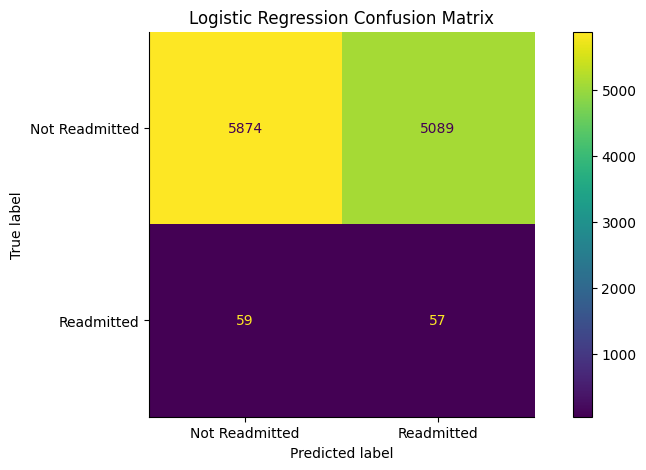

In [6]:
# ─────────────────────────────────────────────────────────────
# Model 1: Logistic Regression Baseline with Scaling
# ─────────────────────────────────────────────────────────────
# In this step, I train my first baseline model for predicting whether a patient will be readmitted within 30 days.
#
# I use Logistic Regression because it is simple, fast, and easier to explain compared with more complex models.
#
# Since Logistic Regression is sensitive to feature scale, I add StandardScaler before the model.
# This makes numeric features such as age, billing_amount, and length_of_stay_days more comparable.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ─────────────────────────────────────────────────────────────
# Build Logistic Regression Pipeline
# ─────────────────────────────────────────────────────────────
# The pipeline applies two steps:
#
# 1. StandardScaler:
#    Standardizes the feature values so they have a similar scale.
#
# 2. LogisticRegression:
#    Trains the baseline classification model.
#
# class_weight="balanced" is used because only around 1% of admissions are readmitted within 30 days.
# This gives more importance to the rare readmission class during training.

lr_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)


# ─────────────────────────────────────────────────────────────
# Train the Model
# ─────────────────────────────────────────────────────────────

lr_pipeline.fit(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Make Predictions
# ─────────────────────────────────────────────────────────────

# lr_proba gives the predicted probability of readmission.
# I keep column 1 because it represents the positive class.

lr_preds = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate the Model
# ─────────────────────────────────────────────────────────────
# The classification report shows precision, recall, and F1-score.
# For this project, recall for the Readmitted class is very important because missing a high-risk patient could mean missing a chance for early follow-up care.

print("=== Logistic Regression Baseline with Scaling ===")
print(
    classification_report(
        y_test,
        lr_preds,
        target_names=["Not Readmitted", "Readmitted"]
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")


# ─────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────
# The confusion matrix helps me see how many readmitted patients were correctly found and how many were missed.

cm = confusion_matrix(y_test, lr_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

The Logistic Regression baseline model was trained using class balancing because the readmission target is highly imbalanced.

The model achieved an **AUC-ROC score of 0.5179**, which is only slightly better than random guessing. This suggests that the baseline model has weak ability to separate patients who were readmitted within 30 days from those who were not.

From the confusion matrix:

- **5,874** not-readmitted patients were correctly predicted as not readmitted.
- **5,089** not-readmitted patients were incorrectly predicted as readmitted.
- **57** readmitted patients were correctly identified.
- **59** readmitted patients were missed.

For the positive class, `Readmitted`, the model achieved:

- **Precision:** 0.01
- **Recall:** 0.49
- **F1-score:** 0.02

The recall value means the model identified about half of the actual readmission cases. However, the precision is extremely low, meaning the model generated many false positives. In a hospital setting, this would create too many unnecessary high-risk alerts.

Overall, this baseline model is not strong enough for reliable readmission prediction, but it provides a useful starting point. It confirms that the problem is difficult due to the rare positive class and that more advanced approaches are needed.



Negative class    : 43,851
Positive class    : 462
scale_pos_weight  : 94.9

=== XGBoost Classifier ===
                precision    recall  f1-score   support

Not Readmitted       0.99      0.81      0.89     10963
    Readmitted       0.01      0.18      0.02       116

      accuracy                           0.80     11079
     macro avg       0.50      0.50      0.46     11079
  weighted avg       0.98      0.80      0.88     11079

AUC-ROC: 0.4876


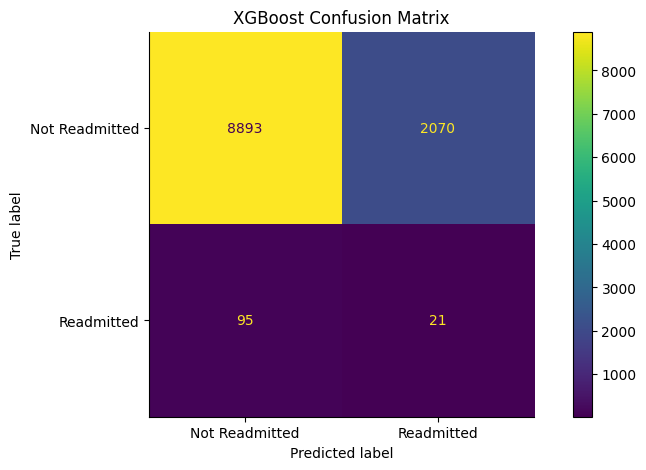

In [7]:
# ─────────────────────────────────────────────────────────────
# Model 2: XGBoost Classifier
# ─────────────────────────────────────────────────────────────
# In this step, I train a stronger model after the Logistic Regression baseline.
#
# XGBoost is a tree-based boosting model. 
# It can capture non-linear patterns and feature interactions that Logistic Regression may miss.
#
# This is useful for readmission prediction because the risk is usually not explained by one feature only.
#  It may depend on combinations such as: age group, medical condition, admission type, length of stay, medication, and test results.
#
# Unlike Logistic Regression, XGBoost does not need StandardScaler because decision trees split data based on feature values and are not sensitive to feature scale.


# ─────────────────────────────────────────────────────────────
# Handle Class Imbalance
# ─────────────────────────────────────────────────────────────
# The readmission class is rare, so I calculate scale_pos_weight.
# scale_pos_weight = number of negative cases / number of positive cases
#
# This gives more weight to the minority class during training, helping the model pay more attention to readmitted patients.

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negative class    : {neg:,}")
print(f"Positive class    : {pos:,}")
print(f"scale_pos_weight  : {scale_pos_weight:.1f}")
print()


# ─────────────────────────────────────────────────────────────
# Build XGBoost Model
# ─────────────────────────────────────────────────────────────
# Main parameters:
#
# n_estimators:
#   Number of boosting trees. I start with 200 as a reasonable baseline.
#
# max_depth:
#   Controls how deep each tree can grow. A depth of 4 allows the model  to learn useful patterns without becoming too complex at this stage.
#
# learning_rate:
#   Controls how much each new tree contributes to the final model.
#
# scale_pos_weight:
#   Helps compensate for the rare readmission class.
#
# eval_metric:
#   logloss is used to evaluate probability-based classification error.

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)


# ─────────────────────────────────────────────────────────────
# Train the Model
# ─────────────────────────────────────────────────────────────

xgb_model.fit(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Make Predictions
# ─────────────────────────────────────────────────────────────


xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate the Model
# ─────────────────────────────────────────────────────────────


print("=== XGBoost Classifier ===")

print(
    classification_report(
        y_test,
        xgb_preds,
        target_names=["Not Readmitted", "Readmitted"]
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")


# ─────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────

cm_xgb = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

The XGBoost classifier was trained as a stronger tree-based model after the Logistic Regression baseline. Because the target variable is highly imbalanced, `scale_pos_weight` was calculated using the ratio between the negative and positive classes in the training data.

The training data contained **43,851 not-readmitted cases** and **462 readmitted cases**, giving a `scale_pos_weight` value of approximately **94.9**. This means the model gave more weight to the minority class during training.

The XGBoost model achieved an **AUC-ROC score of 0.4876**, which indicates weak separation between readmitted and not-readmitted patients.

From the confusion matrix:

- **8,893** not-readmitted patients were correctly predicted as not readmitted.
- **2,070** not-readmitted patients were incorrectly predicted as readmitted.
- **21** readmitted patients were correctly identified.
- **95** readmitted patients were missed.

For the positive class, `Readmitted`, the model achieved:

- **Precision:** 0.01
- **Recall:** 0.18
- **F1-score:** 0.02

The AUC-ROC of 0.4876 is actually slightly below 0.50, meaning the model performs marginally worse than random guessing. This is a known phenomenon with heavily imbalanced synthetic data where the model overfits to noise in the minority class rather than learning real patterns.

Compared with the Logistic Regression baseline, XGBoost produced fewer false positives, but it also missed more actual readmission cases. This means the model became more conservative in predicting readmission, but it was less useful for identifying high-risk patients.

Overall, this result suggests that the current features do not provide enough predictive signal for reliable 30-day readmission prediction. More feature engineering is needed before the model can be considered useful in a healthcare setting.


=== Random Forest Classifier ===
                precision    recall  f1-score   support

Not Readmitted       0.99      0.90      0.94     10963
    Readmitted       0.01      0.07      0.01       116

      accuracy                           0.89     11079
     macro avg       0.50      0.48      0.48     11079
  weighted avg       0.98      0.89      0.93     11079

AUC-ROC: 0.4941
PR-AUC : 0.0101


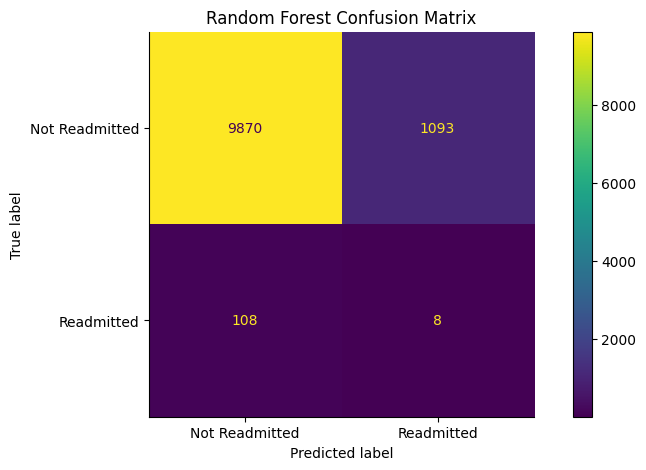

In [8]:
# ─────────────────────────────────────────────────────────────
# Model 3: Random Forest Classifier
# ─────────────────────────────────────────────────────────────
# In this step, I train a Random Forest model as another tree-based approach for predicting 30-day readmission.
#
# Random Forest builds many decision trees and combines their predictions.
# This usually makes it more stable than a single decision tree.
#
# Like XGBoost, Random Forest can capture non-linear relationships and interactions between features.
# This is useful because readmission risk may depend on combinations of patient, admission, and clinical factors.
#
# Random Forest does not require feature scaling because it is based on decision trees.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)


# ─────────────────────────────────────────────────────────────
# Build Random Forest Model
# ─────────────────────────────────────────────────────────────
# Main parameters:
#
# n_estimators=200:
#   Builds 200 trees. 
# This gives the model enough trees to make stable predictions without being too slow.
#
# max_depth=6:
#   Limits how deep each tree can grow. This helps reduce overfitting.
#
# class_weight="balanced":
#   Gives more weight to the rare readmission class, because only around  1% of admissions are readmitted within 30 days.


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ─────────────────────────────────────────────────────────────
# Train the Model
# ─────────────────────────────────────────────────────────────

rf_model.fit(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Make Predictions
# ─────────────────────────────────────────────────────────────

rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate the Model
# ─────────────────────────────────────────────────────────────

print("=== Random Forest Classifier ===")

print(
    classification_report(
        y_test,
        rf_preds,
        target_names=["Not Readmitted", "Readmitted"]
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"PR-AUC : {average_precision_score(y_test, rf_proba):.4f}")


# ─────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────


cm_rf = confusion_matrix(y_test, rf_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

The Random Forest model was trained using `class_weight="balanced"` to help handle the highly imbalanced readmission target.

The model achieved an **accuracy of 0.89**, which may look strong at first. However, this accuracy is misleading because the dataset is highly imbalanced and most admissions belong to the `Not Readmitted` class.

From the confusion matrix:

- **9,870** not-readmitted patients were correctly predicted as not readmitted.
- **1,093** not-readmitted patients were incorrectly predicted as readmitted.
- **8** readmitted patients were correctly identified.
- **108** readmitted patients were missed.

For the positive class, `Readmitted`, the model achieved:

- **Precision:** 0.01
- **Recall:** 0.07
- **F1-score:** 0.01

This means the Random Forest model identified only **7%** of the actual readmission cases. In a healthcare setting, this is not strong enough because the main goal is to identify high-risk patients before they return to the hospital.

The model also achieved:

- **AUC-ROC:** 0.4941
- **PR-AUC:** 0.0101

The PR-AUC score is especially important because the positive class is very rare. A PR-AUC close to the readmission rate suggests that the model is not learning a strong signal for predicting readmission.

Compared with the previous models, Random Forest produced fewer false positives, but it missed more actual readmission cases. Therefore, it is not the best model for this use case.

At this stage, Logistic Regression remains the better baseline for identifying more readmitted patients because it achieved the highest recall for the `Readmitted` class. However, all models need improvement through stronger feature engineering and better clinical risk variables.

=== XGBoost Threshold Tuning ===
 Threshold  Precision     Recall         F1        AUC
-------------------------------------------------------
      0.03      0.010      0.931      0.020     0.4876
      0.05      0.010      0.905      0.020     0.4876
      0.08      0.010      0.879      0.020     0.4876
      0.10      0.010      0.836      0.020     0.4876
      0.15      0.010      0.784      0.020     0.4876

Best threshold based on F1-score: 0.08
Best F1-score                  : 0.020

=== XGBoost Classification Report with Tuned Threshold ===
                precision    recall  f1-score   support

Not Readmitted       0.99      0.09      0.16     10963
    Readmitted       0.01      0.88      0.02       116

      accuracy                           0.10     11079
     macro avg       0.50      0.48      0.09     11079
  weighted avg       0.98      0.10      0.16     11079



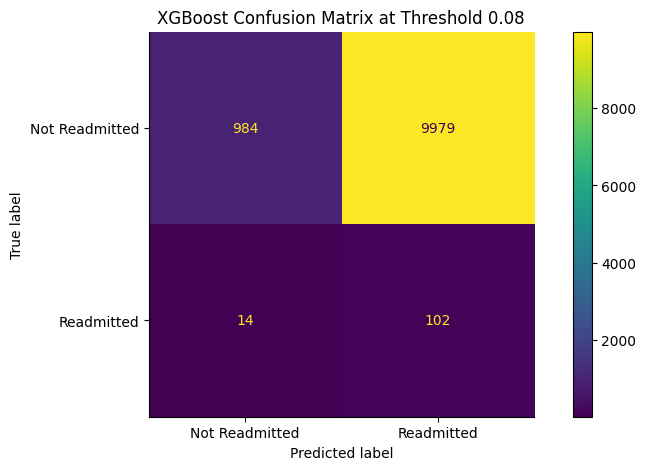

In [9]:
# ─────────────────────────────────────────────────────────────
# XGBoost Threshold Tuning
# ─────────────────────────────────────────────────────────────
# By default, classification models usually predict class 1 when the predicted probability is 0.50 or higher.
#
# In this project, the positive class is very rare. 
# Only around 1% of admissions are readmitted within 30 days.
#
# Because of that, using the default 0.50 threshold may be too strict.
# The model may give many patients a low probability, even if some of them are still relatively high-risk compared with the rest of the data.
#
# To handle this, I test lower thresholds such as 0.03, 0.05, and 0.10.
#
# Lower threshold:
#   - catches more readmitted patients
#   - increases recall
#   - usually creates more false positives
#
# Higher threshold:
#   - creates fewer false positives
#   - usually improves precision
#   - may miss more actual readmission cases

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# These are the thresholds I want to test.

thresholds = [0.03, 0.05, 0.08, 0.10, 0.15]


print("=== XGBoost Threshold Tuning ===")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 55)


# I will track the threshold with the best F1-score.
# F1 is a balance between precision and recall.
best_f1 = 0
best_threshold = None
best_preds = None



auc = roc_auc_score(y_test, xgb_proba)


# Try each threshold and calculate precision, recall, and F1-score.
for threshold in thresholds:
    
    # Convert probabilities into class predictions using the current threshold.
    # If probability >= threshold, predict 1 = Readmitted.
    # Otherwise, predict 0 = Not Readmitted.
    preds_threshold = (xgb_proba >= threshold).astype(int)
    
    # Calculate evaluation metrics for the Readmitted class.
    precision = precision_score(y_test, preds_threshold, zero_division=0)
    recall = recall_score(y_test, preds_threshold, zero_division=0)
    f1 = f1_score(y_test, preds_threshold, zero_division=0)
    
    
    print(
        f"{threshold:>10.2f} "
        f"{precision:>10.3f} "
        f"{recall:>10.3f} "
        f"{f1:>10.3f} "
        f"{auc:>10.4f}"
    )
    
    # Keep the threshold that gives the best F1-score.
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_preds = preds_threshold


print()
print(f"Best threshold based on F1-score: {best_threshold}")
print(f"Best F1-score                  : {best_f1:.3f}")


# ─────────────────────────────────────────────────────────────
# Final Report Using Best Threshold
# ─────────────────────────────────────────────────────────────


print()
print("=== XGBoost Classification Report with Tuned Threshold ===")
print(
    classification_report(
        y_test,
        best_preds,
        target_names=["Not Readmitted", "Readmitted"]
    )
)


# ─────────────────────────────────────────────────────────────
# Confusion Matrix Using Best Threshold
# ─────────────────────────────────────────────────────────────


cm_threshold = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title(f"XGBoost Confusion Matrix at Threshold {best_threshold}")
plt.show()

Threshold tuning was applied to the XGBoost model to test whether lowering the classification threshold could improve detection of readmitted patients.

By default, classification models usually use a threshold of 0.50. In this experiment, lower thresholds were tested because the positive class, `Readmitted`, represents only about 1% of the dataset.

The best threshold based on F1-score was **0.08**.

At this threshold, the model achieved the following results for the `Readmitted` class:

- **Precision:** 0.01
- **Recall:** 0.88
- **F1-score:** 0.02

From the confusion matrix:

- **984** not-readmitted patients were correctly predicted as not readmitted.
- **9,979** not-readmitted patients were incorrectly predicted as readmitted.
- **102** readmitted patients were correctly identified.
- **14** readmitted patients were missed.

The main improvement from threshold tuning was recall. The model identified **102 out of 116** actual readmission cases, meaning it detected about **88%** of readmitted patients.

However, this came at a very high cost. The model also produced **9,979 false positives**, meaning many patients were incorrectly flagged as high risk. This caused precision to remain extremely low at **0.01**.

This result shows the trade-off between recall and precision. A lower threshold helps catch more at-risk patients, but it also creates many false alarms.

In a healthcare setting, this threshold could be useful only as a broad screening tool, where the goal is to avoid missing patients who may need follow-up care. However, it would not be practical as a final alert system because the number of false positives is too high.

Overall, threshold tuning improved recall but did not solve the model’s weak precision. More feature engineering and stronger clinical predictors are needed to build a more reliable readmission risk model.

Before SMOTE:
  Not Readmitted: 43,851
  Readmitted    : 462

After SMOTE:
  Not Readmitted: 43,851
  Readmitted    : 43,851

=== XGBoost + SMOTE ===
                precision    recall  f1-score   support

Not Readmitted       0.99      0.87      0.93     10963
    Readmitted       0.01      0.13      0.02       116

      accuracy                           0.86     11079
     macro avg       0.50      0.50      0.47     11079
  weighted avg       0.98      0.86      0.92     11079

AUC-ROC: 0.5066
PR-AUC : 0.0113


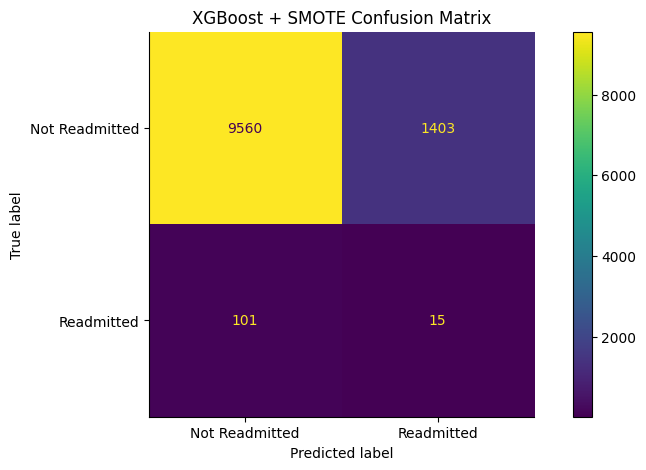

In [10]:
# ─────────────────────────────────────────────────────────────
# SMOTE Oversampling
# ─────────────────────────────────────────────────────────────
# In this step, I try another method to handle the class imbalance problem.
#
# The dataset is highly imbalanced because only around 1% of admissions are readmitted within 30 days.
#
# SMOTE stands for Synthetic Minority Oversampling Technique.
# It creates new synthetic examples for the minority class instead of simply duplicating existing readmission cases.
#
# The idea is:
# - Find similar minority-class examples
# - Create new synthetic points between them
# - Give the model more readmission patterns to learn from




from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)


# ─────────────────────────────────────────────────────────────
# Check Class Balance Before SMOTE
# ─────────────────────────────────────────────────────────────
# Before applying SMOTE, I print the class counts in the training set.
# This confirms how imbalanced the training data is.

print("Before SMOTE:")
print(f"  Not Readmitted: {(y_train == 0).sum():,}")
print(f"  Readmitted    : {(y_train == 1).sum():,}")


# ─────────────────────────────────────────────────────────────
# Apply SMOTE to Training Data Only
# ─────────────────────────────────────────────────────────────


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Check Class Balance After SMOTE
# ─────────────────────────────────────────────────────────────
# After SMOTE, the minority class should have more samples.
# By default, SMOTE balances the classes to the same size.

print("\nAfter SMOTE:")
print(f"  Not Readmitted: {(y_train_smote == 0).sum():,}")
print(f"  Readmitted    : {(y_train_smote == 1).sum():,}")


# ─────────────────────────────────────────────────────────────
# Train XGBoost on SMOTE-Balanced Data
# ─────────────────────────────────────────────────────────────
# I train XGBoost again, but this time using the SMOTE-balanced training data.
#


xgb_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb_smote.fit(X_train_smote, y_train_smote)


# ─────────────────────────────────────────────────────────────
# Make Predictions on Original Test Set
# ─────────────────────────────────────────────────────────────


smote_preds = xgb_smote.predict(X_test)
smote_proba = xgb_smote.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate XGBoost + SMOTE
# ─────────────────────────────────────────────────────────────


print("\n=== XGBoost + SMOTE ===")

print(
    classification_report(
        y_test,
        smote_preds,
        target_names=["Not Readmitted", "Readmitted"]
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test, smote_proba):.4f}")
print(f"PR-AUC : {average_precision_score(y_test, smote_proba):.4f}")


# ─────────────────────────────────────────────────────────────
# Confusion Matrix
# ─────────────────────────────────────────────────────────────

cm_smote = confusion_matrix(y_test, smote_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("XGBoost + SMOTE Confusion Matrix")
plt.show()

SMOTE was applied only to the training set to address the severe class imbalance in the readmission target.

Before SMOTE, the training data contained **43,851 not-readmitted cases** and only **462 readmitted cases**. After applying SMOTE, the training data became balanced, with **43,851 records in each class**.

The model was then trained on the SMOTE-balanced training data and evaluated on the original unchanged test set.

From the confusion matrix:

- **9,560** not-readmitted patients were correctly predicted as not readmitted.
- **1,403** not-readmitted patients were incorrectly predicted as readmitted.
- **15** readmitted patients were correctly identified.
- **101** readmitted patients were missed.

For the positive class, `Readmitted`, the model achieved:

- **Precision:** 0.01
- **Recall:** 0.13
- **F1-score:** 0.02

This means the model identified only **13%** of the actual readmission cases. Although SMOTE balanced the training data, it did not significantly improve the model’s ability to detect readmitted patients on the real test set.

The model achieved an **AUC-ROC of 0.5066** and a **PR-AUC of 0.0113**. Since the positive class is very rare, PR-AUC is especially important. A PR-AUC close to the original readmission rate suggests that the model is not learning a strong predictive signal.



In [11]:
# ─────────────────────────────────────────────────────────────
# Model Comparison Summary
# ─────────────────────────────────────────────────────────────
# In this step, I compare all models in one summary table.
# Since the target class is highly imbalanced, I do not rely on accuracy.
# Instead, I compare:
#
# Precision:
#   Out of all patients predicted as readmitted, how many were actually readmitted?
#
# Recall:
#   Out of all actual readmitted patients, how many did the model catch?
#
# F1-score:
#   A balance between precision and recall.
#
# AUC-ROC:
#   Measures how well the model separates the two classes overall.
#
# PR-AUC:
#   Precision-Recall AUC. This is especially important when the positive class is rare, like this 30-day readmission problem.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


results = []



models = [
    ("Logistic Regression",       lr_preds,     lr_proba),
    ("XGBoost",                   xgb_preds,    xgb_proba),
    ("Random Forest",             rf_preds,     rf_proba),
    ("XGBoost + Threshold 0.08",  best_preds,   xgb_proba),
    ("XGBoost + SMOTE",           smote_preds,  smote_proba),
]


for model_name, preds, proba in models:
    
    results.append({
        "Model": model_name,
        

        "Precision": round(precision_score(y_test, preds, zero_division=0), 3),
        "Recall": round(recall_score(y_test, preds, zero_division=0), 3),
        "F1": round(f1_score(y_test, preds, zero_division=0), 3),
        
        "AUC-ROC": round(roc_auc_score(y_test, proba), 4),
        "PR-AUC": round(average_precision_score(y_test, proba), 4),
    })


# Convert the list of dictionaries into a DataFrame.
comparison = pd.DataFrame(results)


comparison = comparison.set_index("Model")


print(comparison.to_string())

                          Precision  Recall     F1  AUC-ROC  PR-AUC
Model                                                              
Logistic Regression           0.011   0.491  0.022   0.5179  0.0108
XGBoost                       0.010   0.181  0.019   0.4876  0.0113
Random Forest                 0.007   0.069  0.013   0.4941  0.0101
XGBoost + Threshold 0.08      0.010   0.879  0.020   0.4876  0.0113
XGBoost + SMOTE               0.011   0.129  0.020   0.5066  0.0113


The model comparison table shows that all tested models struggled to predict 30-day readmission reliably.

The main challenge is the severe class imbalance, where only about 1% of admissions resulted in a 30-day readmission. Because of this, accuracy was not used as the main evaluation metric. Instead, the comparison focused on precision, recall, F1-score, AUC-ROC, and PR-AUC.

Among the standard models, **Logistic Regression** achieved the highest recall for the `Readmitted` class, with a recall of **0.491**. This means it identified about 49% of actual readmission cases. However, its precision was only **0.011**, meaning it also produced many false positive alerts.

The **XGBoost + Threshold 0.08** model achieved the highest recall overall, with a recall of **0.879**. This means it captured most of the actual readmission cases. However, its precision remained extremely low at **0.010**, showing that it flagged too many patients as high risk. This model may be useful as a broad screening approach, but it would not be practical as a final alert system without further improvement.

The Random Forest, standard XGBoost, and XGBoost + SMOTE models did not significantly improve performance. Their recall values were lower, and their PR-AUC scores stayed close to the baseline readmission rate.

The PR-AUC values for all models were close to **0.01**, which is approximately the positive class rate in the dataset. This suggests that the models are not learning a strong predictive signal from the current features.

Overall, the results suggest that the issue is not only class imbalance. Even after applying class weighting, threshold tuning, and SMOTE, the models still performed poorly. This indicates that the current feature set is likely too limited for reliable readmission prediction.



Computing SHAP values...


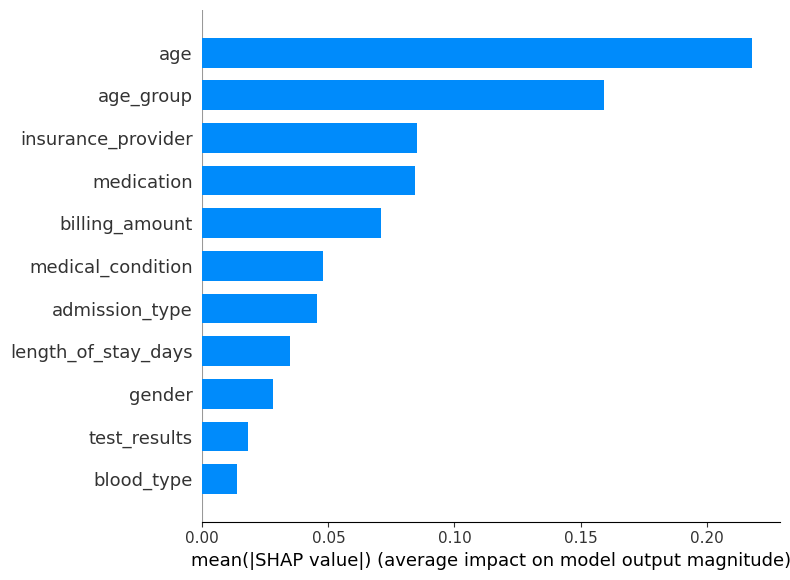

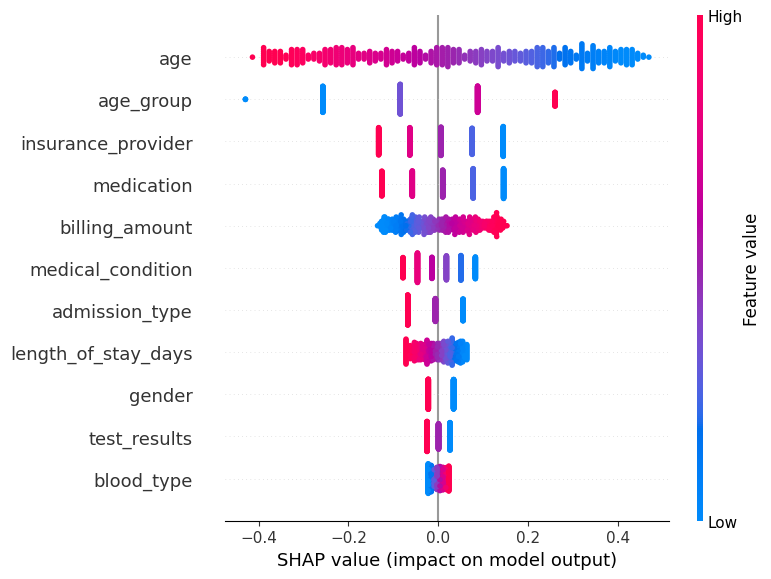


Feature importance by mean absolute SHAP value:
            feature  mean_abs_shap
                age       0.218198
          age_group       0.159447
 insurance_provider       0.085020
         medication       0.084210
     billing_amount       0.070933
  medical_condition       0.047662
     admission_type       0.045304
length_of_stay_days       0.034746
             gender       0.028172
       test_results       0.017952
         blood_type       0.013596


In [12]:
# ─────────────────────────────────────────────────────────────
# SHAP Explainability -Logistic Regression
# ─────────────────────────────────────────────────────────────
# SHAP explains how much each feature contributed to each individual prediction.
#
# For Logistic Regression we use LinearExplainer instead of TreeExplainer because the model is linear, not tree-based.
#
# We use a sample of 500 rows for speed.

print("Computing SHAP values...")

sample      = X_test.sample(500, random_state=42)
explainer   = shap.LinearExplainer(
    lr_pipeline.named_steps["model"],
    shap.maskers.Independent(
        lr_pipeline.named_steps["scaler"].transform(X_train)
    )
)
shap_values = explainer.shap_values(
    lr_pipeline.named_steps["scaler"].transform(sample)
)

shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# ── Bar plot - global feature importance ──────────────────────
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar",
    show=True
)

# ── Beeswarm - direction and magnitude ────────────────────────
shap.summary_plot(
    shap_values,
    sample,
    show=True
)

# ── Mean absolute SHAP per feature ────────────────────────────
mean_shap = pd.DataFrame({
    "feature"    : X_test.columns,
    "mean_abs_shap": np.abs(shap_df).mean()
}).sort_values("mean_abs_shap", ascending=False)

print("\nFeature importance by mean absolute SHAP value:")
print(mean_shap.to_string(index=False))

SHAP was used to explain the Logistic Regression baseline model and identify which features had the largest impact on the model’s predictions.

Based on the mean absolute SHAP values, the most influential features were:

- **age**
- **age_group**
- **insurance_provider**
- **medication**
- **billing_amount**
- **medical_condition**
- **admission_type**
- **length_of_stay_days**

The strongest feature was `age`, with a mean absolute SHAP value of **0.2182**, followed by `age_group` with **0.1594**. This suggests that age-related variables had the largest influence on the model’s readmission predictions.

The SHAP bar plot shows the global importance of each feature, while the beeswarm plot shows both the size and direction of each feature’s impact. Features with wider spread, such as `age` and `age_group`, had a stronger effect on the model output. Features such as `blood_type` and `test_results` had much smaller average impact.

However, these results should be interpreted carefully. The Logistic Regression model had weak predictive performance overall, so the SHAP values explain the behaviour of the current model, not necessarily true clinical causes of readmission.

Another important limitation is that categorical variables were encoded using `LabelEncoder`. This means categories such as insurance provider, medication, blood type, and medical condition were converted into numeric labels. These numeric labels do not represent a real clinical order, so the direction of their SHAP impact should not be over-interpreted.



In [13]:
shap_readm = pd.DataFrame({
    "feature"       : X_test.columns,
    "mean_abs_shap" : np.abs(shap_values).mean(axis=0),
    "model"         : "Readmission Risk"
}).sort_values("mean_abs_shap", ascending=False).head(10)

shap_readm.to_csv("../data/processed/shap_readmission.csv", index=False)
print(shap_readm)

                feature  mean_abs_shap             model
0                   age       0.218198  Readmission Risk
1             age_group       0.159447  Readmission Risk
6    insurance_provider       0.085020  Readmission Risk
10           medication       0.084210  Readmission Risk
8        billing_amount       0.070933  Readmission Risk
4     medical_condition       0.047662  Readmission Risk
5        admission_type       0.045304  Readmission Risk
7   length_of_stay_days       0.034746  Readmission Risk
2                gender       0.028172  Readmission Risk
9          test_results       0.017952  Readmission Risk


In [14]:
import pandas as pd
from pathlib import Path

shap_er    = pd.read_csv("../data/processed/shap_er_wait.csv")
shap_readm = pd.read_csv("../data/processed/shap_readmission.csv")

shap_combined = pd.concat([shap_er, shap_readm], ignore_index=True)
shap_combined.to_csv("../data/processed/shap_combined.csv", index=False)
print(shap_combined)

                feature  mean_abs_shap              model
0         urgency_level      47.337780  ER Wait Predictor
1                season      12.589968  ER Wait Predictor
2           time_of_day      12.128141  ER Wait Predictor
3           day_of_week       9.138750  ER Wait Predictor
4   nurse_patient_ratio       5.730321  ER Wait Predictor
5         facility_beds       1.243841  ER Wait Predictor
6            visit_hour       0.942204  ER Wait Predictor
7      specialist_count       0.738476  ER Wait Predictor
8           visit_month       0.473810  ER Wait Predictor
9                   age       0.218198   Readmission Risk
10            age_group       0.159447   Readmission Risk
11   insurance_provider       0.085020   Readmission Risk
12           medication       0.084210   Readmission Risk
13       billing_amount       0.070933   Readmission Risk
14    medical_condition       0.047662   Readmission Risk
15       admission_type       0.045304   Readmission Risk
16  length_of_

In [15]:
import joblib
from pathlib import Path

# Save the trained pipeline and encoders
joblib.dump(lr_pipeline, "../models/lr_readmission_model.pkl")
joblib.dump(encoders,    "../models/lr_encoders.pkl")

# Save the feature column order
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, "../models/feature_columns.pkl")

print("Saved:")
print(f"  lr_readmission_model.pkl")
print(f"  lr_encoders.pkl")
print(f"  feature_columns.pkl")
print(f"  Features: {feature_cols}")

Saved:
  lr_readmission_model.pkl
  lr_encoders.pkl
  feature_columns.pkl
  Features: ['age', 'age_group', 'gender', 'blood_type', 'medical_condition', 'admission_type', 'insurance_provider', 'length_of_stay_days', 'billing_amount', 'test_results', 'medication']
